## Step 1: Load data and rebuild focal_term → PMID mapping

In [89]:
import pandas as pd

# Raw sources
df_pat  = pd.read_parquet('../data/raw/SampleGloria_Pat_GlinerLabels.parquet')   # patent_id, term
df_pmed = pd.read_parquet('../data/raw/SampleGloria_Pmed_GlinerLabels.parquet')  # pmid (int), term
df_link = pd.read_parquet('../data/raw/SampleGloria_Link_PmidOa.parquet')        # patent_id, pmid (URL)

# Pre-computed focal terms (aggregated)
df_focal = pd.read_parquet('../output/focal_terms.parquet')     # patent_id, focal_term

print('Pat rows:  ', len(df_pat))
print('Pmed rows: ', len(df_pmed))
print('Link rows: ', len(df_link))
print('Focal rows:', len(df_focal))

Pat rows:   23312
Pmed rows:  31831
Link rows:  6104
Focal rows: 790


In [90]:
# Clean link table: extract numeric pmid from URL, drop rows without pmid
df_link_clean = df_link.dropna(subset=['pmid']).copy()
df_link_clean['pmid'] = df_link_clean['pmid'].str.extract(r'(\d+)$').astype('int32')
df_link_clean = df_link_clean[['patent_id', 'pmid']].drop_duplicates()
print('patent-pmid pairs:', len(df_link_clean))

patent-pmid pairs: 3997


In [91]:
# Merge pmed terms with patent_id via the link table
cited_terms = df_pmed[['pmid', 'term']].merge(df_link_clean, on='pmid', how='inner')

# Rebuild focal_terms_with_pmid:
#   A (patent_id, term) is a focal term if it appears in both
#   the patent AND in at least one cited paper of that patent.
patent_term_set = df_pat[['patent_id', 'term']].drop_duplicates()
focal_with_pmid = patent_term_set.merge(
    cited_terms[['patent_id', 'pmid', 'term']].drop_duplicates(),
    on=['patent_id', 'term'],
    how='inner'
).rename(columns={'term': 'focal_term'})

print('focal_with_pmid shape:', focal_with_pmid.shape)
focal_with_pmid.head()

focal_with_pmid shape: (1743, 3)


,patent_id,focal_term,pmid
0,7662783,effective,17483349
1,7662783,antagonist,11387236
2,7662783,collagen,11387236
3,7662783,collagen,11535623
4,7662783,collagen,17110907


## Step 2: Build patent context per (patent_id, focal_term)

Patent context = **set of all terms in the patent** minus the focal term itself.

In [92]:
# Unique terms per patent (as a dict: patent_id -> frozenset of terms)
patent_term_sets = (
    df_pat.groupby('patent_id')['term']
          .apply(set)
          .to_dict()
)
print('Patents with term sets:', len(patent_term_sets))

Patents with term sets: 252


## Step 3: Build paper context per (patent_id, focal_term)

Paper context = **set of all terms** in the PMIDs where the focal term appears (for that patent) minus the focal term.

In [93]:
# For each (patent_id, focal_term) → set of relevant PMIDs
focal_pmids = (
    focal_with_pmid.groupby(['patent_id', 'focal_term'])['pmid']
                   .apply(set)
                   .reset_index(name='pmid_set')
)

# Build a dict: pmid -> set of terms (from pmed)
pmid_term_sets = (
    df_pmed.groupby('pmid')['term']
           .apply(set)
           .to_dict()
)
print('PMIDs with term sets:', len(pmid_term_sets))

PMIDs with term sets: 706


In [94]:
def paper_context(pmid_set, focal_term):
    """Union of terms across the relevant PMIDs, minus the focal term."""
    terms = set()
    for pmid in pmid_set:
        terms |= pmid_term_sets.get(pmid, set())
    terms.discard(focal_term)
    return terms

focal_pmids['paper_ctx'] = focal_pmids.apply(
    lambda r: paper_context(r['pmid_set'], r['focal_term']), axis=1
)
focal_pmids.head(3)

,patent_id,focal_term,pmid_set,paper_ctx
0,7662783,alpha,{11387236},"{tumor, αvβ3, phosphorylation, laminin-1, acti..."
1,7662783,antagonist,{11387236},"{tumor, αvβ3, phosphorylation, laminin-1, acti..."
2,7662783,cell,"{12746434, 11535623, 12071856, 12454288, 17483...","{anti-tumor, responsible, conformational, αvβ3..."


In [95]:
rows = []
for _, row in focal_pmids.iterrows():
    pid   = row['patent_id']
    ft    = row['focal_term']
    
    # Patent context: all patent terms minus the focal term
    pat_ctx = patent_term_sets.get(pid, set()) - {ft}
    
    # Paper context already computed
    pap_ctx = row['paper_ctx']
    
    
    rows.append({
        'patent_id':          pid,
        'focal_term':         ft,
        'pmids':              row['pmid_set'],
        'patent_context':     pat_ctx,
        'paper_context':      pap_ctx
    })

focal_term_contexts = pd.DataFrame(rows)
focal_term_contexts.to_parquet("../output/focal_term_context.parquet")
focal_term_contexts.head()


,patent_id,focal_term,pmids,patent_context,paper_context
0,7662783,alpha,{11387236},"{least, bladder, ovary, total, beams, pharynx,...","{tumor, αvβ3, phosphorylation, laminin-1, acti..."
1,7662783,antagonist,{11387236},"{least, bladder, ovary, total, beams, pharynx,...","{tumor, αvβ3, phosphorylation, laminin-1, acti..."
2,7662783,cell,"{12746434, 11535623, 12071856, 12454288, 17483...","{least, bladder, ovary, total, beams, pharynx,...","{anti-tumor, responsible, conformational, αvβ3..."
3,7662783,collagen,"{17110907, 11387236, 11535623}","{least, bladder, ovary, total, beams, pharynx,...","{alphavbeta3, αvβ3, significant, alpha1beta1, ..."
4,7662783,colon,{12746434},"{least, bladder, ovary, total, beams, pharynx,...","{anti-tumor, responsible, chick, neovasculariz..."


In [96]:
patent_sentences = [f"{row['focal_term']} {' '.join(row['patent_context'])}" for _, row in focal_term_contexts.iterrows()]
patent_sentences                               

['alpha least bladder ovary total beams pharynx amount colorectal bone neutrons kaposi effective intestine x-rays testicle sarcoma method comprising gamma cell antagonist tumors patient about administered breast therapy neuroblastoma treating peptide prostate negative pi mesons electrons administering proliferation pancreas colon stomach head lymph node neutron kidney effect tumor comprises electron increases neck sensitivity radiation therapy sweat gland gy lung cervix combination melanoma particles joint solid endometrius at skin amino acid amino acid sequence treatment uterus larynx proton growth glioblastoma radiation liver sequence solid tumor marrow beta synergistic collagen',
 'antagonist least bladder ovary total beams pharynx amount colorectal bone neutrons kaposi effective intestine x-rays testicle sarcoma alpha method comprising gamma cell tumors patient about administered breast therapy neuroblastoma treating peptide prostate negative pi mesons electrons administering proli

In [97]:
paper_sentences = [f"{row['focal_term']} {' '.join(row['paper_context'])}" for _, row in focal_term_contexts.iterrows()]
paper_sentences  

['alpha tumor αvβ3 phosphorylation laminin-1 activity matrix potent capillary-like antagonist gamma1 adhesion functional important screening angiogenic block differentiate metastasis receptor peptide role likely therapeutic α5β1 healing chain ubiquitous growth wound vivo surface alpha5beta1 laminin binding chromatography bind attachment and fibronectin site beta3 collagen',
 'antagonist tumor αvβ3 phosphorylation laminin-1 activity matrix alpha potent capillary-like gamma1 adhesion functional important screening angiogenic block differentiate metastasis receptor peptide role likely therapeutic α5β1 healing chain ubiquitous growth wound vivo surface alpha5beta1 laminin binding chromatography bind attachment and fibronectin site beta3 collagen',
 'cell anti-tumor responsible conformational αvβ3 significant development molecule alpha1beta1 behavior cyclin-dependent description selectively functionally domain important functional multivalent significance codistributes consequence peptide a

In [98]:
from sentence_transformers import SentenceTransformer
#sentences = ["This is an example sentence", "Each sentence is converted"]

#model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
#embeddings = model.encode(sentences)
 #print(embeddings)


In [99]:
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Encode both lists — index i of patent_embeddings corresponds to index i of paper_embeddings
patent_embeddings = model.encode(patent_sentences, show_progress_bar=True)
paper_embeddings  = model.encode(paper_sentences,  show_progress_bar=True)

print("patent_embeddings shape:", patent_embeddings.shape)
print("paper_embeddings shape: ", paper_embeddings.shape)

# Quick sanity check: first pair
print("\nFirst patent sentence:", patent_sentences[0][:80], "...")
print("First paper sentence: ", paper_sentences[0][:80], "...")
print("patent_embeddings[0]:", patent_embeddings[0][:5], "...")
print("paper_embeddings[0]: ", paper_embeddings[0][:5], "...")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8778.62it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 25/25 [00:04<00:00,  5.77it/s]

patent_embeddings shape: (790, 384)
paper_embeddings shape:  (790, 384)

First patent sentence: alpha least bladder ovary total beams pharynx amount colorectal bone neutrons ka ...
First paper sentence:  alpha tumor αvβ3 phosphorylation laminin-1 activity matrix potent capillary-like ...
patent_embeddings[0]: [-0.03189786 -0.00332399 -0.03137472 -0.01033427 -0.0595785 ] ...
paper_embeddings[0]:  [-0.07680508 -0.10017946 -0.0684163  -0.03515213  0.07670909] ...


In [100]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Cosine similarity between each patent/paper embedding pair (row-wise)
similarities = cosine_similarity(patent_embeddings, paper_embeddings).diagonal()

focal_term_contexts['cosine_similarity'] = similarities

print(focal_term_contexts[['patent_id', 'focal_term', 'cosine_similarity']].head(50))
focal_term_contexts.to_parquet("../output/cosine_similarity_results.parquet")

   patent_id       focal_term  cosine_similarity
0    7662783            alpha           0.392647
1    7662783       antagonist           0.394412
2    7662783             cell           0.213458
3    7662783         collagen           0.278174
4    7662783            colon           0.306966
5    7662783           effect           0.224122
6    7662783        effective           0.291127
7    7662783           growth           0.311352
8    7662783             lung           0.300341
9    7662783         melanoma           0.336211
10   7662783          peptide           0.393241
11   7662783    proliferation           0.376872
12   7662783         sequence           0.116856
13   7662783             skin           0.297021
14   7662783        treatment           0.289045
15   7662783            tumor           0.295498
16   7700783            agent           0.184918
17   7700783         hydroxyl           0.254190
18   7704363              and           0.234530
19   7704363    conc

Cosine Similarity Statistics
  Mean:   0.433
  Median: 0.431
  Std:    0.141
  Min:    0.007
  Max:    0.896


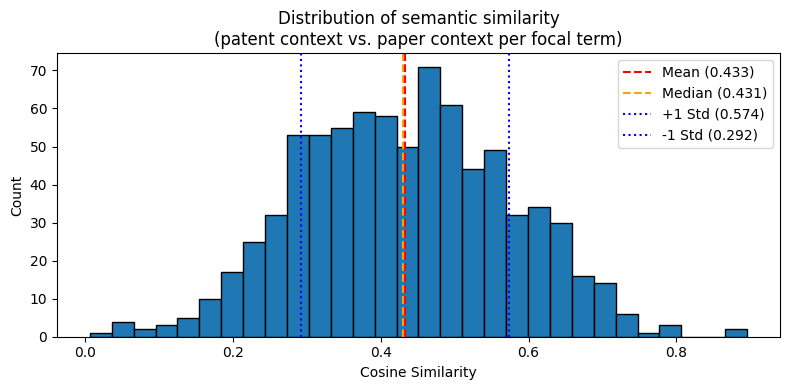

In [101]:
import matplotlib.pyplot as plt

sim = focal_term_contexts['cosine_similarity']

# --- Quantitative summary ---
print("Cosine Similarity Statistics")
print(f"  Mean:   {sim.mean():.3f}")
print(f"  Median: {sim.median():.3f}")
print(f"  Std:    {sim.std():.3f}")
print(f"  Min:    {sim.min():.3f}")
print(f"  Max:    {sim.max():.3f}")

# --- Histogram ---
plt.figure(figsize=(8, 4))
plt.hist(sim, bins=30, edgecolor='black')
plt.axvline(sim.mean(),              color='red',    linestyle='--', label=f'Mean ({sim.mean():.3f})')
plt.axvline(sim.median(),            color='orange', linestyle='--', label=f'Median ({sim.median():.3f})')
plt.axvline(sim.mean() + sim.std(),  color='blue',   linestyle=':',  label=f'+1 Std ({sim.mean()+sim.std():.3f})')
plt.axvline(sim.mean() - sim.std(),  color='blue',   linestyle=':',  label=f'-1 Std ({sim.mean()-sim.std():.3f})')
plt.xlabel('Cosine Similarity')
plt.ylabel('Count')
plt.title('Distribution of semantic similarity\n(patent context vs. paper context per focal term)')
plt.legend()
plt.tight_layout()
plt.savefig("../visualizations/cosine_similarity_distribution.png", dpi=150)
plt.show()

In [102]:
n = 5  # number of examples to show

top = focal_term_contexts.nlargest(n, 'cosine_similarity')[['patent_id', 'focal_term', 'patent_context', 'paper_context', 'cosine_similarity']]
bot = focal_term_contexts.nsmallest(n, 'cosine_similarity')[['patent_id', 'focal_term', 'patent_context', 'paper_context', 'cosine_similarity']]

print("=== HIGH similarity (focal term used in similar contexts) ===")
for _, row in top.iterrows():
    print(f"\nFocal term: '{row['focal_term']}'  (patent_id={row['patent_id']},  sim={row['cosine_similarity']:.3f})")
    print(f"  Patent ctx (sample): {', '.join(list(row['patent_context'])[:10])}")
    print(f"  Paper  ctx (sample): {', '.join(list(row['paper_context'])[:10])}")

print("\n=== LOW similarity (focal term used in different contexts) ===")
for _, row in bot.iterrows():
    print(f"\nFocal term: '{row['focal_term']}'  (patent_id={row['patent_id']},  sim={row['cosine_similarity']:.3f})")
    print(f"  Patent ctx (sample): {', '.join(list(row['patent_context'])[:10])}")
    print(f"  Paper  ctx (sample): {', '.join(list(row['paper_context'])[:10])}")

=== HIGH similarity (focal term used in similar contexts) ===

Focal term: 'asbestos-related'  (patent_id=8168398,  sim=0.896)
  Patent ctx (sample): presence, chest, value, reference, asbestos, pleural mesothelioma, amount, develop, diagnostic, pleural
  Paper  ctx (sample): presence, milliliter, asbestos, significant, value, nonmalignant, mean, pleural, sensitivity, mesothelioma

Focal term: 'presence'  (patent_id=8168398,  sim=0.879)
  Patent ctx (sample): chest, value, reference, asbestos, pleural mesothelioma, amount, develop, diagnostic, pleural, having
  Paper  ctx (sample): milliliter, asbestos, significant, value, nonmalignant, mean, pleural, sensitivity, mesothelioma, analysis

Focal term: 'asbestos'  (patent_id=8168398,  sim=0.805)
  Patent ctx (sample): presence, chest, value, reference, pleural mesothelioma, amount, develop, diagnostic, pleural, having
  Paper  ctx (sample): fivefold, thereafter, chest, milliliter, significant, value, development, unlikely, independent, he